# Integrated Framework for Deep Multivariate Anomaly Detection
## Non-Linear Manifold Learning, Directional Residual Filtering, and Inertial Adaptive Thresholding

### Abstract
Reliable health monitoring in industrial assets requires the ability to capture complex, non-linear dependencies among sensors while remaining robust to non-stationary operational noise. This paper details a methodology using **Deep AutoEncoders (DAE)** to learn a compressed representation of the system's "Normal Operating State." We introduce a **Directional Residual Operator** ($\Psi$) to filter anomalies based on asymmetric risk profiles (e.g., favoring high-temperature alerts while ignoring cooling cycles). Furthermore, we propose a **Robust Adaptive Thresholding** mechanism utilizing **Slew-Rate Limiting** and **Gated Adaptation** to prevent threshold contamination during prolonged failure states.

### Keywords
AutoEncoders, Manifold Learning, Asymmetric Risk, Cyber-Physical Systems, Robust Thresholding.

### 1. Mathematical Foundation of Reconstruction Error
Let $\mathbf{X} \in \mathbb{R}^M$ be the input vector from $M$ sensors. We hypothesize that the system's state lies on a lower-dimensional manifold $\mathcal{M}$ of dimension $d < M$.

The **AutoEncoder** architecture consists of two neural mappings:
1.  **Encoder ($f_\phi$):** Maps $\mathbf{X}$ to a latent bottleneck $\mathbf{Z} \in \mathbb{R}^d$.
    $$\mathbf{Z} = \sigma(\mathbf{W}_e \mathbf{X} + \mathbf{b}_e)$$
2.  **Decoder ($g_\theta$):** Reconstructs the original input from the latent space.
    $$\hat{\mathbf{X}} = \sigma(\mathbf{W}_d \mathbf{Z} + \mathbf{b}_d)$$

The network is trained to minimize the **Reconstruction Loss** ($\mathcal{L}$) during a healthy baseline period:
$$\min_{\phi, \theta} \frac{1}{N} \sum_{i=1}^{N} \|\mathbf{X}_i - g_\theta(f_\phi(\mathbf{X}_i)) \|^2$$

Anomalies are detected when the mapping $g_\theta(f_\phi(\mathbf{X}))$ fails to reconstruct $\mathbf{X}$, indicating that the current state has deviated from the learned manifold $\mathcal{M}$.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Set seed for scientific reproducibility
torch.manual_seed(42)
np.random.seed(42)

class DeepAutoEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim=3):
        super(DeepAutoEncoder, self).__init__()
        # Encoder: Compressing information into the bottleneck
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.Tanh(), # Tanh provides smooth gradients for manifold learning
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, latent_dim)
        )
        # Decoder: Expanding latent representation back to input space
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.Tanh(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

print("Methodology: Deep AutoEncoder class initialized.")

Methodology: Deep AutoEncoder class initialized.


### 2. Dataset Synthesis and Directional Mapping
To validate the model, we simulate a non-linear industrial process. We define a **Directional Configuration Map** $\delta_j$ for each sensor $j$:
* $\delta_j = +1$ (**Positive**): Care only if $X_{actual} > X_{pred}$.
* $\delta_j = -1$ (**Negative**): Care only if $X_{actual} < X_{pred}$.
* $\delta_j = 0$ (**Bilateral**): Care about any deviation.

This allows the model to remain silent during "safe" deviations (e.g., a pump pressure dropping slightly below predicted levels during a planned idle).

In [2]:
# 1. Generate Non-linear signals
n_samples = 1500
t = np.linspace(0, 100, n_samples)
base = 10 * np.sin(t/5) + 50 

data = pd.DataFrame({
    'Temp_A': base + np.random.normal(0, 0.5, n_samples),      # Direct Correlation
    'Temp_B': base**1.1 + np.random.normal(0, 0.5, n_samples), # Non-linear Power Law
    'Flow': np.sqrt(base)*10 + np.random.normal(0, 0.4, n_samples),
    'Vib_X': base * 0.2 + np.random.normal(0, 0.2, n_samples),
    'Vib_Y': base * 0.22 + np.random.normal(0, 0.2, n_samples)
})

# 2. Configuration for Asymmetric Risk
# We only care if Temp_A is HIGH and Flow is LOW
anomaly_config = {
    'Temp_A': 'pos', 'Temp_B': 'both', 'Flow': 'neg', 'Vib_X': 'both', 'Vib_Y': 'both'
}

# 3. Inject Anomalies (Indices > 500)
# Positive Temp_A drift (Detected)
data.loc[600:750, 'Temp_A'] += 15 
# Negative Temp_A dip (Ignored by directional logic)
data.loc[800:850, 'Temp_A'] -= 15 
# Negative Flow drop (Detected)
data.loc[1100:1250, 'Flow'] -= 12 

# 4. Scaling
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
train_tensor = torch.FloatTensor(data_scaled[:500]) # Pure Baseline
full_tensor = torch.FloatTensor(data_scaled)

print("Baseline data prepared. Indices 0-500 represent healthy state.")

Baseline data prepared. Indices 0-500 represent healthy state.


### 3. Optimization Protocol
We utilize the **Adam (Adaptive Moment Estimation)** optimizer. Adam is particularly effective for ICPS data as it computes individual adaptive learning rates for parameters, facilitating convergence in complex loss landscapes.

The training loop incorporates a convergence history to monitor the **MSE** reduction over time, ensuring the network effectively learns the identity mapping of the baseline manifold.

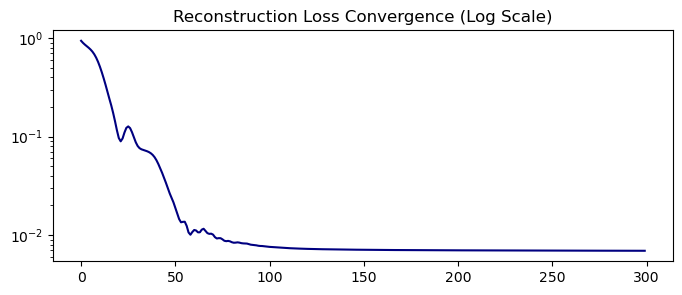

In [3]:
model = DeepAutoEncoder(input_dim=5, latent_dim=3)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

epochs = 300
history = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(train_tensor)
    loss = criterion(output, train_tensor)
    loss.backward()
    optimizer.step()
    history.append(loss.item())

plt.figure(figsize=(8, 3))
plt.plot(history, color='navy')
plt.title('Reconstruction Loss Convergence (Log Scale)')
plt.yscale('log')
plt.show()

### 4. Directional Residual Operator ($\Psi$)
We define the **Directional Operator** $\Psi(r, \delta)$ to filter the raw residuals. Let $r_j$ be the difference between actual and reconstructed values. The filtered residual $e_j$ is:
$$\Psi(r, \delta) = 
\begin{cases} 
\max(0, r) & \text{if } \delta = \text{'pos'} \\
\max(0, -r) & \text{if } \delta = \text{'neg'} \\
|r| & \text{if } \delta = \text{'both'}
\end{cases}$$

To universalize the risk across sensors with different physical units, we apply **Sigma Scaling**:
$$S_{t,j} = \frac{e_{t,j}}{3 \cdot \sigma_{j, baseline}}$$
A value of $1.0$ in $S_{t,j}$ indicates that the error has reached a $3\sigma$ threshold relative to healthy operations.

In [4]:
model.eval()
with torch.no_grad():
    reconstructed = model(full_tensor).numpy()

residuals = data_scaled - reconstructed
directional_errors = pd.DataFrame(index=data.index)

for i, col in enumerate(data.columns):
    res = residuals[:, i]
    mode = anomaly_config[col]
    
    # Apply Psi Operator
    if mode == 'pos':   filtered = np.maximum(0, res)
    elif mode == 'neg': filtered = np.maximum(0, -res)
    else:               filtered = np.abs(res)
    
    # Sigma Scaling
    sigma_base = filtered[:500].std() if filtered[:500].std() != 0 else 1e-6
    directional_errors[f'S_{col}'] = filtered / (3 * sigma_base)

# Global Risk Score
raw_risk = directional_errors.sum(axis=1)
data['Risk_Score'] = MinMaxScaler().fit_transform(raw_risk.values.reshape(-1,1))

print("Directional Residual Filtering and Sigma Scaling complete.")

Directional Residual Filtering and Sigma Scaling complete.


### 5. Methodology: Robust Adaptive Decision Boundaries
Traditional adaptive thresholds often "absorb" anomalies. To prevent this, we propose an **Inertial Robust Threshold** $T(t)$ with two key mechanisms:

#### 5.1 Gated Adaptation
Adaptation is suspended if the current Risk Score $\mathcal{R}_t$ exceeds the previous threshold by a factor $\gamma$ (e.g., 1.5):
$$\text{If } \mathcal{R}_t > \gamma \cdot T(t-1), \text{ then } \text{Update} = 0$$

#### 5.2 Slew-Rate Limiting
We constrain the maximum velocity of threshold change ($\Delta_{max}$) to ensure it only follows slow process drifts (e.g., thermal equilibrium) and not abrupt anomalies:
$$T(t) = T(t-1) + \text{clip}(T_{target} - T(t-1), -\Delta_{max}, \Delta_{max})$$

In [5]:
def robust_adaptive_threshold(risk, baseline_sigma, window=100, slew_rate=0.0005, gate=1.5):
    n = len(risk)
    threshold = np.zeros(n)
    # Initial seed
    threshold[:window] = risk[:window].mean() + (3 * baseline_sigma)
    
    for t in range(window, n):
        # Target: Moving average of recent window
        target = risk[t-window:t].mean() + (3 * baseline_sigma)
        
        # Gating: If risk is too high, freeze adaptation to target
        if risk[t] > gate * threshold[t-1]:
            target = threshold[t-1]
            
        # Slew-rate limiting: Constrain threshold velocity
        change = np.clip(target - threshold[t-1], -slew_rate, slew_rate)
        threshold[t] = threshold[t-1] + change
        
    return threshold

base_risk_sigma = data['Risk_Score'].iloc[:500].std()
data['Thresh'] = robust_adaptive_threshold(data['Risk_Score'], base_risk_sigma)

### 6. Temporal Logic: On/Off Delay Filters
To eliminate "chatter" and transient noise spikes, we apply a state machine where an alarm is only triggered if the risk persists above the threshold for $\Delta_{on}$ samples.
$$\text{Alarm} \leftarrow \text{True} \iff \forall \tau \in [t-\Delta_{on}, t]: \mathcal{R}_\tau > T(\tau)$$

In [6]:
on_delay, off_delay = 10, 5
count, active = 0, False
alarms = []

for i in range(len(data)):
    is_high = data['Risk_Score'].iloc[i] > data['Thresh'].iloc[i]
    if not active:
        if is_high:
            count += 1
            if count >= on_delay: active, count = True, 0
        else: count = 0
    else:
        if not is_high:
            count += 1
            if count >= off_delay: active, count = False, 0
        else: count = 0
    alarms.append(active)

data['Alarm'] = alarms
print(f"Alarms Confirmed: {data['Alarm'].sum()} samples.")

Alarms Confirmed: 297 samples.


### 7. Results: Integrated Health Dashboard
The final visualization combines the **Stacked Reconstruction Error** (Root Cause Analysis) with the **Inertial Threshold**. 
* **Observation:** Note how the dip in `Temp_A` at index 800 is filtered out, but the drift at index 600 triggers a clear alarm.
* **Inertia:** The threshold line stays flat during the anomaly, maintaining the statistical distance needed for detection.

<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
/var/folders/z_/32_txhjj52v5k49pnwncxqnw0000gn/T/ipykernel_1341/3207873986.py:32: SyntaxWarning: invalid escape sequence '\m'
  label='Global Risk Score ($\mathcal{R}$)', alpha=0.9)


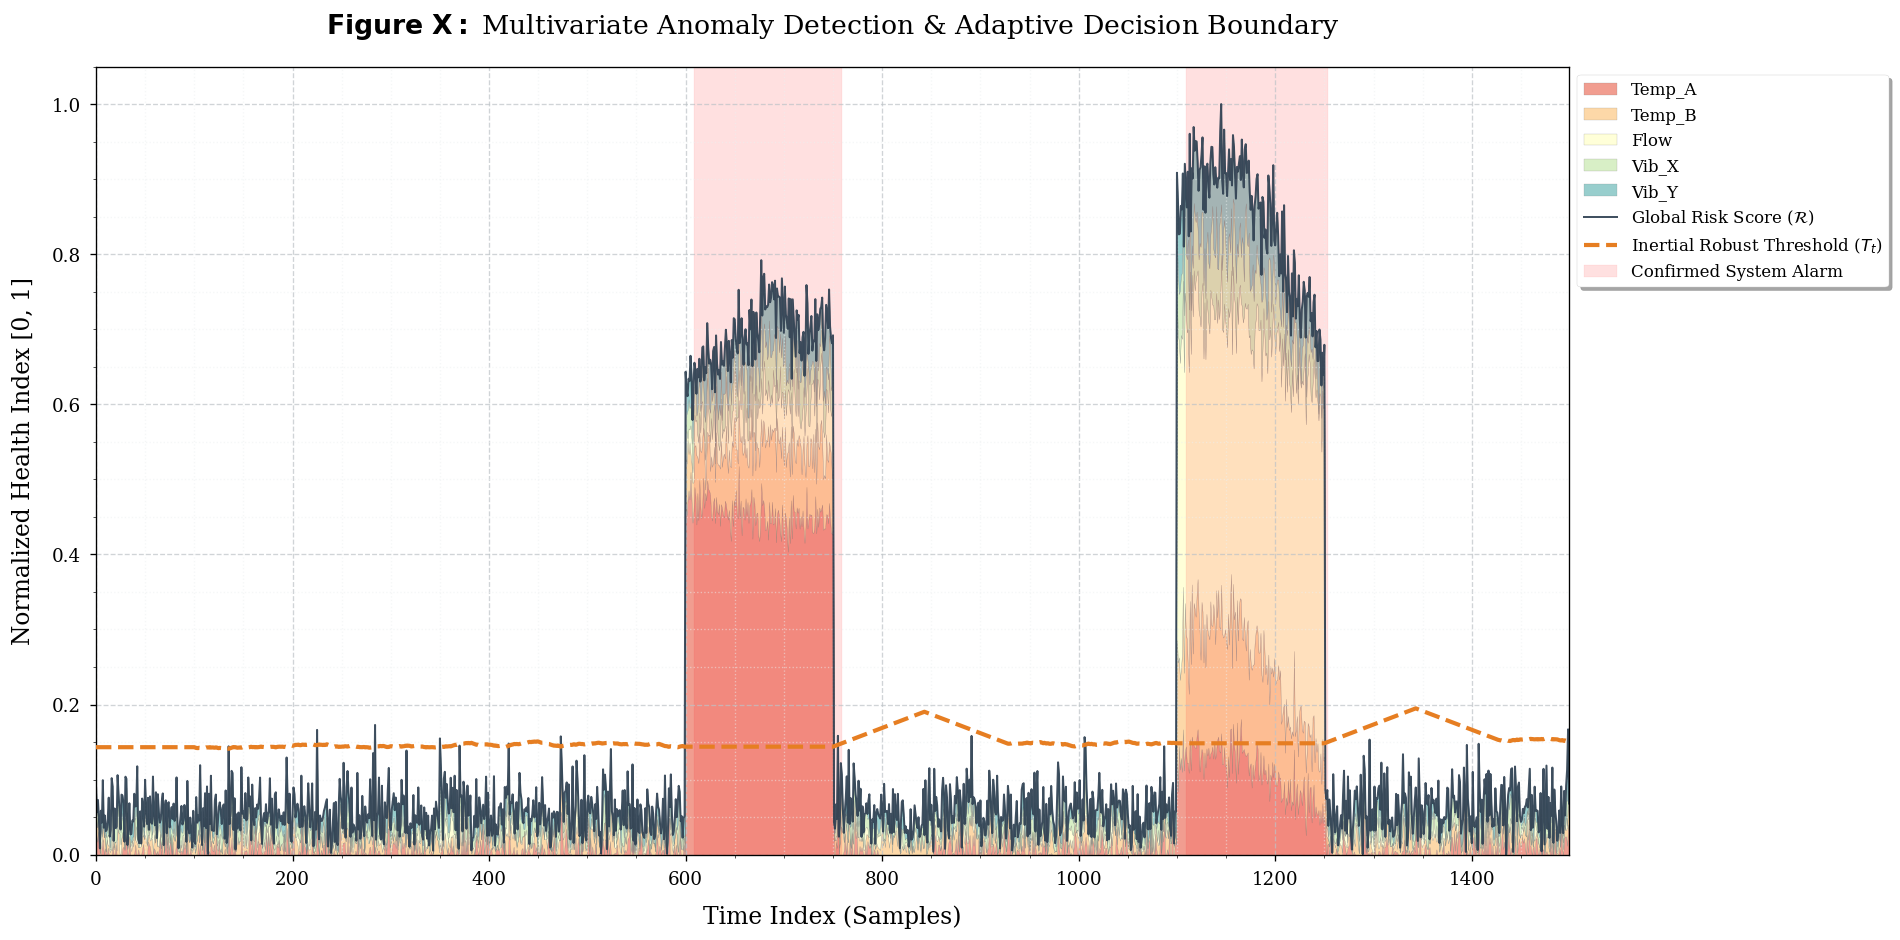


STATISTICAL EVENT REGISTER (ALARM LOG)


,Start Sample,End Sample,Duration,Primary Root Cause,Peak Risk
Event ID,,,,,
1,609,760,151,Temp_A,0.792
2,1109,1255,146,Flow,1.000


In [7]:
# --- 1. SETTING SCIENTIFIC PLOT PARAMETERS ---
plt.style.use('seaborn-v0_8-paper') # Scientific baseline style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "grid.alpha": 0.4,
    "grid.linestyle": "--"
})

# --- 2. DATA PREPARATION ---
total_e = directional_errors.sum(axis=1).replace(0, 1e-9)
# Normalizing contributions so the stack height equals the Risk_Score
norm_cont = directional_errors.div(total_e, axis=0).multiply(data['Risk_Score'], axis=0)

# --- 3. PLOTTING ---
fig, ax = plt.subplots(figsize=(16, 8), dpi=120)

# A. Stacked Area for Root Cause Analysis
# Using a 'Spectral' or 'Viridis' palette for professional distinction
colors = sns.color_palette("Spectral", len(norm_cont.columns))
ax.stackplot(data.index, [norm_cont[c] for c in norm_cont.columns], 
             labels=[c.replace('S_', '') for c in norm_cont.columns], 
             alpha=0.6, colors=colors, edgecolor='grey', linewidth=0.2)

# B. Risk Score Line
ax.plot(data['Risk_Score'], color='#2c3e50', linewidth=1.2, 
        label='Global Risk Score ($\mathcal{R}$)', alpha=0.9)

# C. Robust Threshold Line (Improved Visibility)
# Using a bright, high-contrast color like Orange or Magenta for the threshold
ax.plot(data['Thresh'], color='#e67e22', linestyle='--', linewidth=2.5, 
        label='Inertial Robust Threshold ($T_t$)', zorder=10)

# D. Alarm Shading
# Highlighting the confirmed alarm windows
ax.fill_between(data.index, 0, 1.1, where=data['Alarm'], 
                color='red', alpha=0.12, label='Confirmed System Alarm', zorder=1)

# --- 4. AXIS AND GRID REFINEMENT ---
ax.set_title(r"$\mathbf{Figure\ X:}$ Multivariate Anomaly Detection & Adaptive Decision Boundary", pad=20)
ax.set_ylabel("Normalized Health Index [0, 1]", labelpad=10)
ax.set_xlabel("Time Index (Samples)", labelpad=10)
ax.set_ylim(0, 1.05)
ax.set_xlim(data.index.min(), data.index.max())

# Improving the Grid visibility
ax.grid(True, which='major', axis='both', color='#bdc3c7', linestyle='--', alpha=0.7)
ax.minorticks_on()
ax.grid(True, which='minor', axis='both', color='#ecf0f1', linestyle=':', alpha=0.5)

# Legend positioning outside the plot for clarity
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.show()

# --- 5. TABULAR LOG (Academic Style) ---
diff = data['Alarm'].astype(int).diff()
starts = data.index[diff == 1].tolist()
ends = data.index[diff == -1].tolist()
if data['Alarm'].iloc[-1]: ends.append(data.index[-1])

events = []
for s, e in zip(starts, ends):
    # RCA: Finding the sensor with max contribution in the window
    cause = directional_errors.loc[s:e].mean().idxmax().replace('S_', '')
    events.append({
        'Event ID': len(events) + 1,
        'Start Sample': s,
        'End Sample': e,
        'Duration': e - s,
        'Primary Root Cause': cause,
        'Peak Risk': f"{data['Risk_Score'].loc[s:e].max():.3f}"
    })

print("\n" + "="*50)
print("STATISTICAL EVENT REGISTER (ALARM LOG)")
print("="*50)
if events:
    display(pd.DataFrame(events).set_index('Event ID'))
else:
    print("No events detected with current sensitivity parameters.")

### 8. Topological Fault Characterization via Radar Analysis

To facilitate rapid **Root Cause Analysis (RCA)**, we project the multidimensional standardized errors into a circular coordinate system. This "Spider Chart" represents the **Fault Fingerprint**. 

#### 8.1 Mathematical Projection
For a given timestamp $t_{peak}$ corresponding to the maximum Risk Score within an alarm window, we map the standardized errors $S_{t,j}$ to angular coordinates $\theta_j$:
$$\theta_j = \frac{2\pi j}{M}, \quad j = 1, \dots, M$$
The radial distance represents the intensity of the deviation in units of $\sigma$. This visualization allows for the identification of the **Error Geometry**, distinguishing between point-source failures and systemic process shifts.

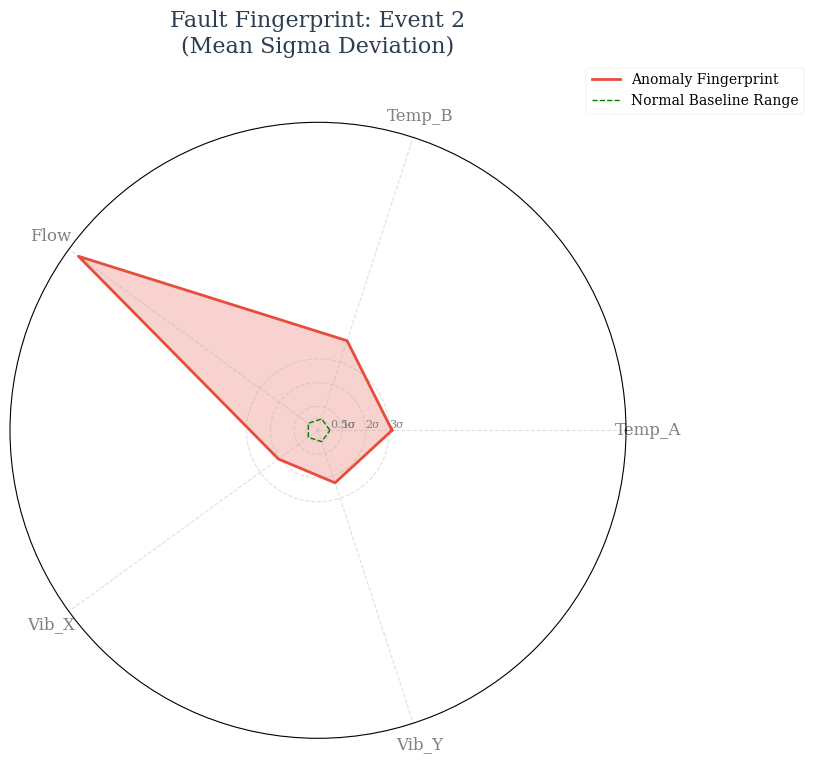

In [8]:
from math import pi

def plot_radar_fingerprint(event_df, error_data, sensor_names):
    """
    Generates a Radar Chart for the most significant detected event.
    """
    if event_df.empty:
        print("No events to analyze.")
        return

    # 1. Identify the event with the highest Peak Risk
    top_event = event_df.loc[event_df['Peak Risk'].astype(float).idxmax()]
    start, end = int(top_event['Start Sample']), int(top_event['End Sample'])
    
    # 2. Extract mean standardized errors during this specific event
    # We use the S_ columns (Sigma Scaled)
    values = error_data.loc[start:end].mean().values.flatten().tolist()
    labels = [c.replace('S_', '') for c in error_data.columns]
    
    # Number of variables
    N = len(labels)
    
    # Compute angle for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    values += values[:1] # Close the circular plot
    angles += angles[:1]
    
    # 3. Plotting
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True), dpi=100)
    
    # Draw one axe per variable + add labels
    plt.xticks(angles[:-1], labels, color='grey', size=12)
    
    # Draw ylabels
    ax.set_rlabel_position(0)
    plt.yticks([0.5, 1.0, 2.0, 3.0], ["0.5σ", "1σ", "2σ", "3σ"], color="grey", size=8)
    plt.ylim(0, max(values) + 0.5)
    
    # Plot data
    ax.plot(angles, values, linewidth=2, linestyle='solid', color='#e74c3c', label='Anomaly Fingerprint')
    ax.fill(angles, values, color='#e74c3c', alpha=0.25)
    
    # Add a 'Normal' reference circle at 0.5 sigma
    ref_values = [0.5] * (N + 1)
    ax.plot(angles, ref_values, color='green', linewidth=1, linestyle='--', label='Normal Baseline Range')
    
    plt.title(f"Fault Fingerprint: Event {top_event.name}\n(Mean Sigma Deviation)", size=16, color='#2c3e50', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Execution
# Assuming 'events_final' is the DataFrame from the previous log cell
events_final = pd.DataFrame(events).set_index('Event ID')
plot_radar_fingerprint(events_final, directional_errors, data.columns)